### Imports

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import math

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms, models

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

### Configuration

In [2]:
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

#########################################################################
########## Décommentez le modèle désiré, commentez les autres. ##########
# MODEL_NAME = "efficientnet_b2"
MODEL_NAME = "resnet50"
#########################################################################

DATA_DIR = "../data/processed/clahe"
MODEL_PATH = f"../models/{MODEL_NAME}/{MODEL_NAME}_best.pth"
PREDICTIONS_PATH = f"../models/{MODEL_NAME}/{MODEL_NAME}_predictions.csv"

if MODEL_NAME == "efficientnet_b2":
    IMG_SIZE = 260
    MOD_NAME = "EfficentNet-B2"
elif MODEL_NAME == "resnet50":
    IMG_SIZE = 224
    MOD_NAME = "ResNet-50"
    
NUM_CLASSES = 4

Device: cuda


### Transformation de la donnée

In [3]:
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### Modèle

In [4]:
if MODEL_NAME == "efficientnet_b2":
    weights = models.EfficientNet_B2_Weights.DEFAULT
    model = models.efficientnet_b2(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
elif MODEL_NAME == "resnet50":
    weights = models.ResNet50_Weights.DEFAULT
    model = models.resnet50(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, NUM_CLASSES)

model.load_state_dict(
    torch.load(MODEL_PATH, map_location=DEVICE)
)

model = model.to(DEVICE)
model.eval()

print(f"Modèle {MODEL_NAME} chargé.")

Modèle resnet50 chargé.


In [13]:
predictions_df = pd.read_csv(PREDICTIONS_PATH)
predictions_df_error_proba_ascending = predictions_df[predictions_df["success"] == 0].sort_values("probability", ascending=True)
predictions_df_error_proba_descending = predictions_df[predictions_df["success"] == 0].sort_values("probability", ascending=False)
predictions_df_success_class_vp = predictions_df[(predictions_df["success"] == 1) & (predictions_df["class"] == "Viral Pneumonia")].sort_values("probability", ascending=False)
display(predictions_df_error_proba_ascending.head())
display(predictions_df_error_proba_descending.head())
display(predictions_df_success_class_vp.head())

,image_name,class,prediction,probability,success
1388,Normal-6974.png,Normal,Lung_Opacity,0.393907,0
1088,Normal-5485.png,Normal,Lung_Opacity,0.414907,0
2888,Lung_Opacity-646.png,Lung_Opacity,COVID,0.437162,0
3500,Lung_Opacity-3749.png,Lung_Opacity,Normal,0.457094,0
2384,COVID-1759.png,COVID,Normal,0.498584,0


,image_name,class,prediction,probability,success
3300,Lung_Opacity-2844.png,Lung_Opacity,Normal,0.999999,0
1002,Normal-5025.png,Normal,Lung_Opacity,0.999989,0
2869,Lung_Opacity-560.png,Lung_Opacity,Normal,0.999972,0
2844,Lung_Opacity-397.png,Lung_Opacity,Normal,0.999943,0
2620,COVID-3000.png,COVID,Normal,0.999941,0


,image_name,class,prediction,probability,success
3987,Viral Pneumonia-132.png,Viral Pneumonia,Viral Pneumonia,1.0,1
3996,Viral Pneumonia-190.png,Viral Pneumonia,Viral Pneumonia,1.0,1
4014,Viral Pneumonia-266.png,Viral Pneumonia,Viral Pneumonia,1.0,1
4138,Viral Pneumonia-848.png,Viral Pneumonia,Viral Pneumonia,1.0,1
4111,Viral Pneumonia-703.png,Viral Pneumonia,Viral Pneumonia,1.0,1


### Grad-CAM

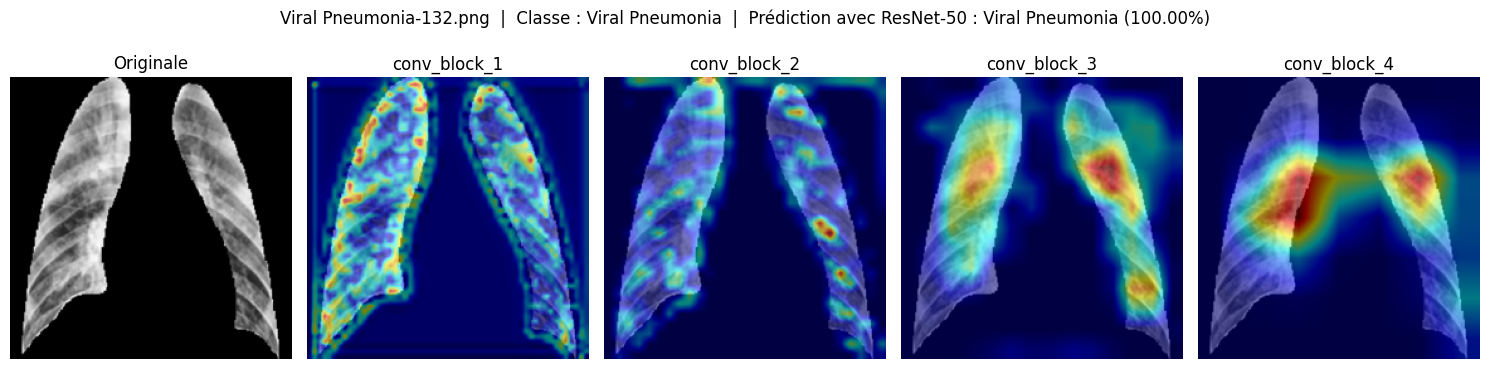

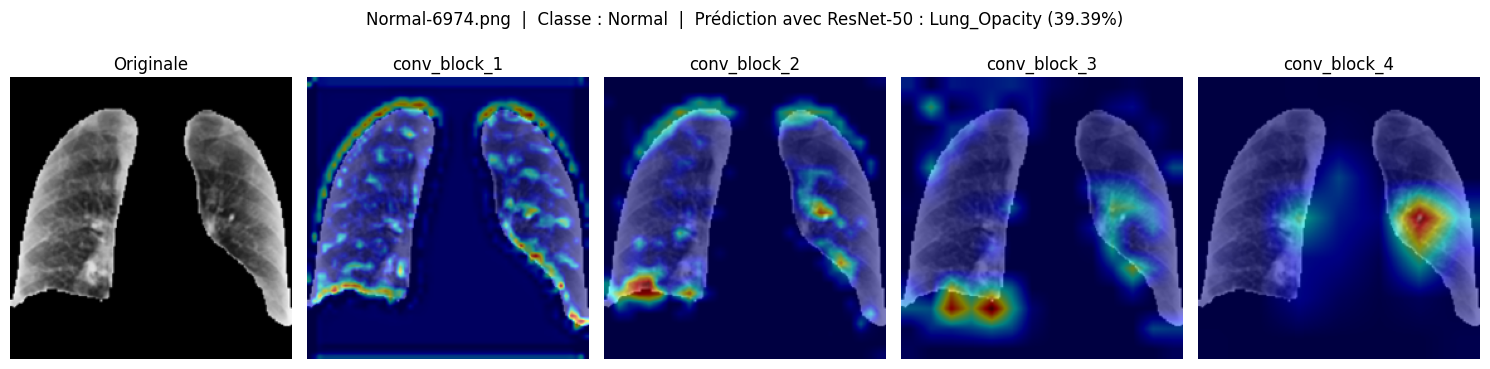

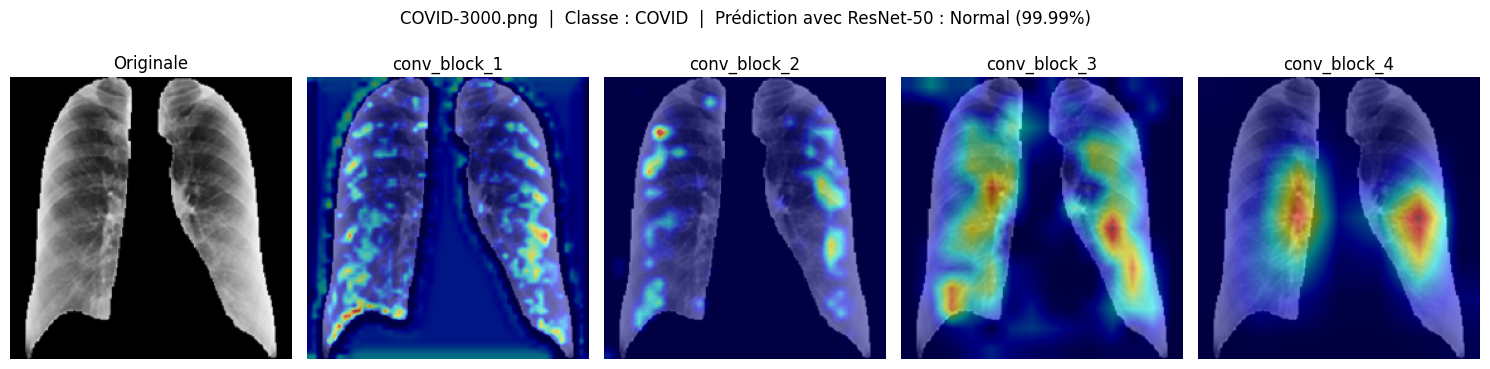

In [15]:
# Image selection
# Cas 1 : prédiction correcte avec forte proba
# Cas 2 : prédiction incorrecte avec faible proba
# Cas 3 : prédiction incorrecte avec forte proba
images = ["Viral Pneumonia-132.png", "Normal-6974.png", "COVID-3000.png"]
for image_name in images:
    image_path = DATA_DIR + f"/{image_name.split('-')[0]}/{image_name}"
    true_class = predictions_df[predictions_df["image_name"] == image_name]["class"].values[0]

    image = Image.open(image_path).convert("L")
    input_tensor = eval_transforms(image).unsqueeze(0).to(DEVICE)
    rgb_img = image.resize((IMG_SIZE, IMG_SIZE))
    rgb_img = np.array(rgb_img).astype(np.float32) / 255.0
    rgb_img = np.stack([rgb_img, rgb_img, rgb_img], axis=-1)

    # Prédiction
    pred_class = predictions_df[predictions_df["image_name"] == image_name]["prediction"].values[0]
    pred_prob = predictions_df[predictions_df["image_name"] == image_name]["probability"].values[0]

    # Grad-CAM
    if MODEL_NAME == "efficientnet_b2":
        target_layers_dict = {
        # "features[0]": [model.features[0]],
        # "features[1]": [model.features[1]],
        "features[2]": [model.features[2]],
        # "features[3]": [model.features[3]],
        "features[4]": [model.features[4]],
        # "features[5]": [model.features[5]],
        "features[6]": [model.features[6]],
        # "features[7]": [model.features[7]],
        "features[8]": [model.features[8]],
    }
        
    elif MODEL_NAME == "resnet50":
        target_layers_dict = {
            "conv_block_1": [model.layer1[-1]],
            "conv_block_2": [model.layer2[-1]],
            "conv_block_3": [model.layer3[-1]],
            "conv_block_4": [model.layer4[-1]],
        }

    visualizations = {}
    for layer_name, target_layers in target_layers_dict.items():
        cam = GradCAM(model=model, target_layers=target_layers)
        grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0, :]
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
        visualizations[layer_name] = visualization

    # Affichage
    n_images = 1 + len(visualizations)
    n_cols = min(5, n_images)
    n_rows = math.ceil(n_images / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows + 1))
    axes = axes.ravel()

    # Image originale
    axes[0].imshow(image.resize((IMG_SIZE, IMG_SIZE)), cmap="gray")
    axes[0].set_title("Originale")
    axes[0].axis("off")

    # Grad-CAM
    for i, (layer_name, visualization) in enumerate(visualizations.items(), start=1):
        axes[i].imshow(visualization)
        axes[i].set_title(layer_name)
        axes[i].axis("off")

    # Désactive les axes inutilisés
    for ax in axes[n_images:]:
        ax.axis("off")

    plt.suptitle(f"{image_name}  |  Classe : {true_class}  |  Prédiction avec {MOD_NAME} : {pred_class} ({pred_prob:.2%})")

    plt.tight_layout()
    plt.show()

